## 0.setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
PALETTE = ['#2E5077', '#4DA1A9', '#79D7BE', '#F6F6F6', '#D8A25E', '#C1440E']
sns.set_palette(PALETTE)


## 1.1 Load and inspect the complete dataset

In [5]:
train = pd.read_csv(r'C:\Users\HP\Downloads\rossmann-store-sales\train.csv', parse_dates=['Date'], low_memory=False)
test = pd.read_csv(r'C:\Users\HP\Downloads\rossmann-store-sales\test.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv(r'C:\Users\HP\Downloads\rossmann-store-sales\store.csv')

print("train shape:", train.shape)
print("test shape :", test.shape)
print("store shape:", store.shape)
train.head()


train shape: (1017209, 9)
test shape : (41088, 8)
store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 1.2 Identify data types for each column

In [6]:
print("TRAIN dtypes:\n", train.dtypes, "\n")
print("TEST dtypes:\n", test.dtypes, "\n")
print("STORE dtypes:\n", store.dtypes)


TRAIN dtypes:
 Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object 

TEST dtypes:
 Id                        int64
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Open                    float64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object 

STORE dtypes:
 Store                          int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: obj

### 1.3 Check for missing values and data quality issues

In [7]:
print("Missing values - train:\n", train.isnull().sum(), "\n")
print("Missing values - test:\n", test.isnull().sum(), "\n")
print("Missing values - store:\n", store.isnull().sum())


Missing values - train:
 Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64 

Missing values - test:
 Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64 

Missing values - store:
 Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


CompetitionDistance           0.3
CompetitionOpenSinceMonth    31.7
CompetitionOpenSinceYear     31.7
Promo2SinceWeek              48.8
Promo2SinceYear              48.8
PromoInterval                48.8
dtype: float64


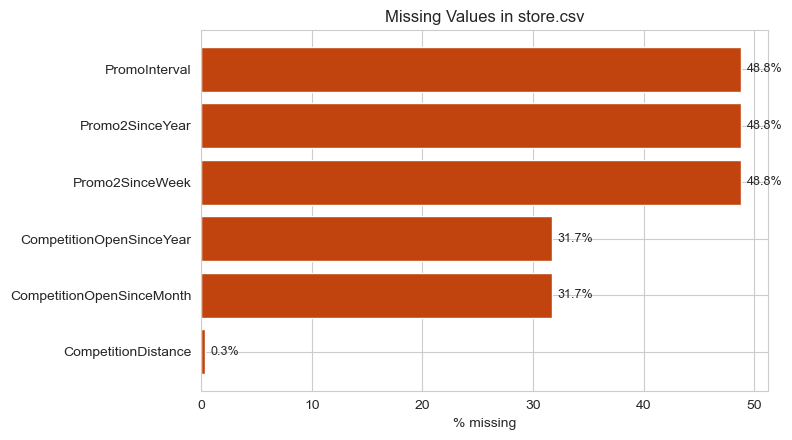

In [8]:
# store.csv missing values as % of rows
miss_pct = (store.isnull().sum() / len(store) * 100).round(1)
print(miss_pct[miss_pct > 0])

fig, ax = plt.subplots(figsize=(8, 4.5))
miss = miss_pct[miss_pct > 0].sort_values()
bars = ax.barh(miss.index, miss.values, color='#C1440E')
ax.set_xlabel('% missing')
ax.set_title('Missing Values in store.csv')
for b, v in zip(bars, miss.values):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height()/2, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


In [9]:
# Sanity checks
print("Rows Open==0 & Sales>0 :", ((train['Open']==0) & (train['Sales']>0)).sum())
print("Rows Open==1 & Sales==0:", ((train['Open']==1) & (train['Sales']==0)).sum())
print("Total rows Sales==0    :", (train['Sales']==0).sum(),
      f"({(train['Sales']==0).mean()*100:.2f}%)")
print("Closed days total      :", (train['Open']==0).sum(),
      f"({(train['Open']==0).mean()*100:.2f}%)")
print("\nTest rows with missing Open:")
test[test['Open'].isnull()][['Store','Date']]


Rows Open==0 & Sales>0 : 0
Rows Open==1 & Sales==0: 54
Total rows Sales==0    : 172871 (16.99%)
Closed days total      : 172817 (16.99%)

Test rows with missing Open:


,Store,Date
479,622,2015-09-17
1335,622,2015-09-16
2191,622,2015-09-15
3047,622,2015-09-14
4759,622,2015-09-12
5615,622,2015-09-11
6471,622,2015-09-10
7327,622,2015-09-09
8183,622,2015-09-08
9039,622,2015-09-07


### 1.4 Generate basic statistical summaries (mean, median, std, min, max)

In [10]:
train.describe(include='all')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1017209,1.017209e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,986159,NaN
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,NaN,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,NaN,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,NaN,1.000000e+00


In [11]:
store.describe(include='all')


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,1115.00000,1115,1115,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000,571
unique,NaN,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,a,a,NaN,NaN,NaN,NaN,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,602,593,NaN,NaN,NaN,NaN,NaN,NaN,335
mean,558.00000,NaN,NaN,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573,NaN
std,322.01708,NaN,NaN,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935,NaN
min,1.00000,NaN,NaN,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000,NaN
25%,279.50000,NaN,NaN,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000,NaN
50%,558.00000,NaN,NaN,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000,NaN
75%,836.50000,NaN,NaN,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000,NaN


In [12]:
sales_stats = train.loc[train['Open']==1, 'Sales'].describe()
print("Sales statistics (open stores only):")
sales_stats


Sales statistics (open stores only):


count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

### 1.5 Analyze data distribution and outliers

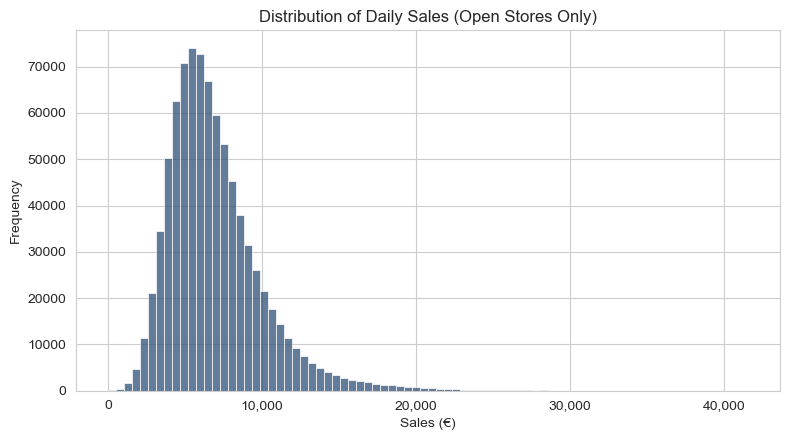

In [13]:
df_open_tmp = train[train['Open']==1]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_open_tmp['Sales'], bins=80, color='#2E5077', ax=ax)
ax.set_title('Distribution of Daily Sales (Open Stores Only)')
ax.set_xlabel('Sales (€)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()


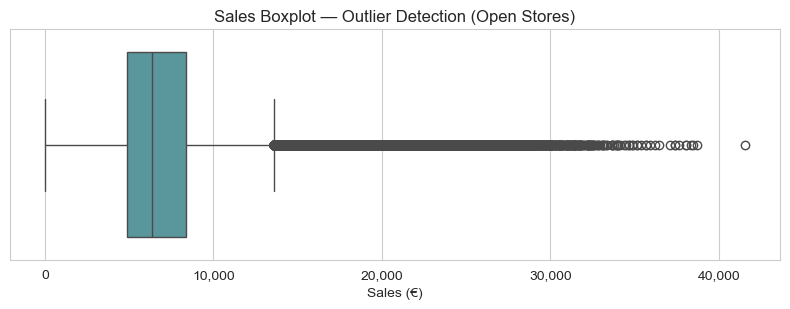

IQR upper bound: 13612
Outliers above bound: 30769 (3.64% of open-store rows)


In [14]:
fig, ax = plt.subplots(figsize=(8, 3.2))
sns.boxplot(x=df_open_tmp['Sales'], color='#4DA1A9', ax=ax)
ax.set_title('Sales Boxplot — Outlier Detection (Open Stores)')
ax.set_xlabel('Sales (€)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()

q1, q3 = df_open_tmp['Sales'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = (df_open_tmp['Sales'] > upper).sum()
print(f"IQR upper bound: {upper:.0f}")
print(f"Outliers above bound: {n_outliers} ({n_outliers/len(df_open_tmp)*100:.2f}% of open-store rows)")


## 2.1 Merge store attributes into train, and prep helper columns

In [15]:
df = train.merge(store, on='Store', how='left')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df_open = df[df['Open'] == 1]
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7


### 2.2 Store — unique stores, distribution across dataset

In [16]:
print("Unique stores in train:", train['Store'].nunique())
print("Unique stores in store.csv:", store['Store'].nunique())
print("Unique stores in test:", test['Store'].nunique())
print("Stores in test not in train:", set(test['Store']) - set(train['Store']))
print("\nDays of history per store (train):")
train.groupby('Store').size().describe()


Unique stores in train: 1115
Unique stores in store.csv: 1115
Unique stores in test: 856
Stores in test not in train: set()

Days of history per store (train):


count    1115.000000
mean      912.295067
std        67.729422
min       758.000000
25%       942.000000
50%       942.000000
75%       942.000000
max       942.000000
dtype: float64

### 2.3 DayOfWeek — weekly patterns

DayOfWeek values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
DayOfWeek
1    8216.0
2    7088.0
3    6728.0
4    6767.0
5    7073.0
6    5875.0
7    8225.0
Name: Sales, dtype: float64


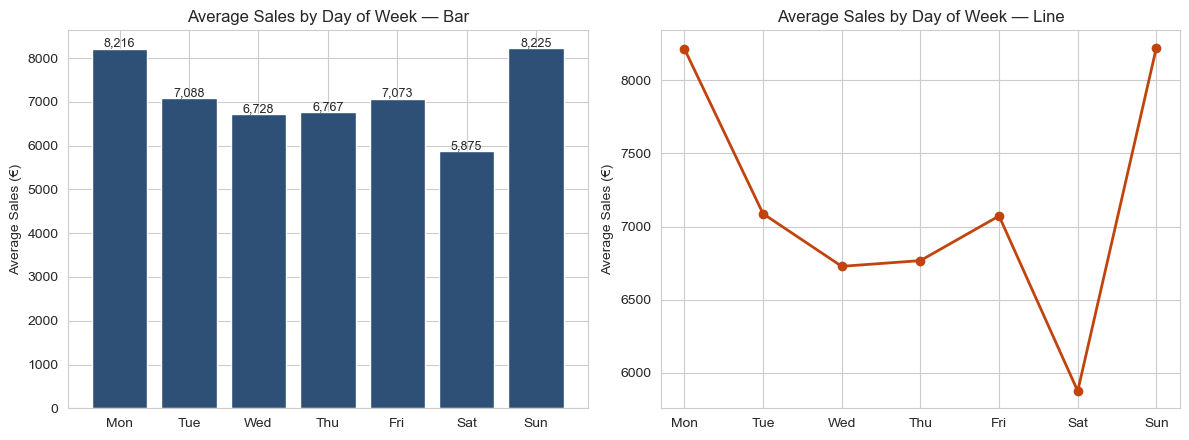

In [17]:
print("DayOfWeek values:", sorted(train['DayOfWeek'].unique()))

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_sales = df_open.groupby('DayOfWeek')['Sales'].mean()
print(dow_sales.round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bars = axes[0].bar([dow_labels[i-1] for i in dow_sales.index], dow_sales.values, color='#2E5077')
axes[0].set_title('Average Sales by Day of Week — Bar')
axes[0].set_ylabel('Average Sales (€)')
for b, v in zip(bars, dow_sales.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+50, f'{v:,.0f}', ha='center', fontsize=9)
axes[1].plot([dow_labels[i-1] for i in dow_sales.index], dow_sales.values,
             color='#C1440E', marker='o', markersize=6, linewidth=2)
axes[1].set_title('Average Sales by Day of Week — Line')
axes[1].set_ylabel('Average Sales (€)')
plt.tight_layout()
plt.show()


## 2.4 Date — seasonal / trend patterns

Date range train: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Date range test : 2015-08-01 00:00:00 to 2015-09-17 00:00:00


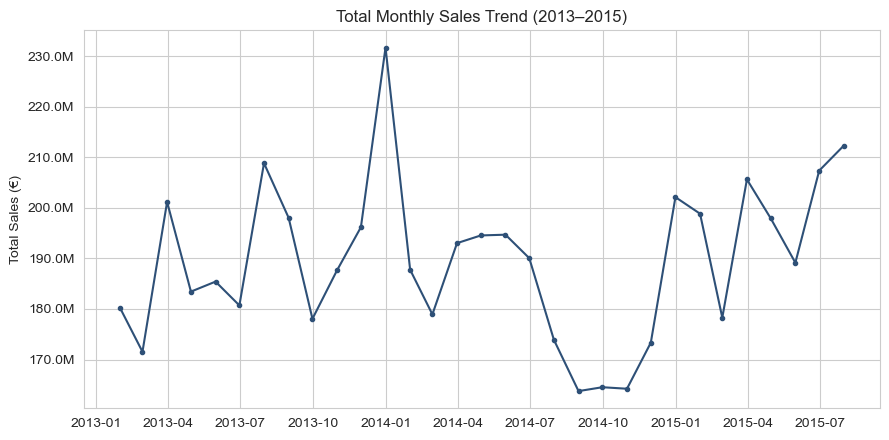

In [18]:
print("Date range train:", train['Date'].min(), "to", train['Date'].max())
print("Date range test :", test['Date'].min(), "to", test['Date'].max())

monthly = df_open.groupby(pd.Grouper(key='Date', freq='ME'))['Sales'].sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, color='#2E5077', marker='o', markersize=3)
ax.set_title('Total Monthly Sales Trend (2013–2015)')
ax.set_ylabel('Total Sales (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


### 2.5 Sales — target variable (see Section 1.4–1.5 for full stats/distribution)

In [19]:
print("Sales is 0 exclusively on closed days, aside from", 
      ((train['Open']==1) & (train['Sales']==0)).sum(), "anomalous open-but-zero-sales rows.")


Sales is 0 exclusively on closed days, aside from 54 anomalous open-but-zero-sales rows.


### 2.6 Customers — relationship with Sales

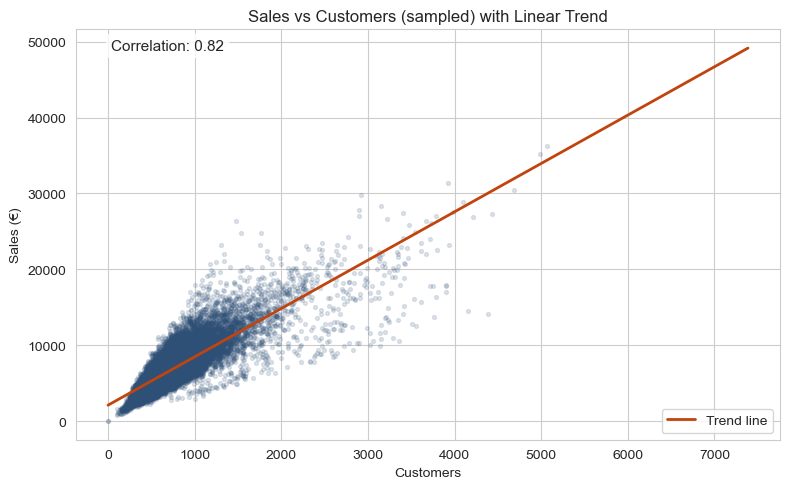

Pearson correlation (Sales, Customers): 0.824


In [20]:
sample = df_open.sample(min(20000, len(df_open)), random_state=42)
corr = df_open[['Customers','Sales']].corr().iloc[0,1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['Customers'], sample['Sales'], alpha=0.15, s=8, color='#2E5077')
coeffs = np.polyfit(df_open['Customers'], df_open['Sales'], 1)
x_line = np.linspace(df_open['Customers'].min(), df_open['Customers'].max(), 100)
ax.plot(x_line, np.polyval(coeffs, x_line), color='#C1440E', linewidth=2, label='Trend line')
ax.set_title('Sales vs Customers (sampled) with Linear Trend')
ax.set_xlabel('Customers')
ax.set_ylabel('Sales (€)')
ax.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Pearson correlation (Sales, Customers): {corr:.3f}")


### 2.7 Open — store operating status

In [21]:
print("% of rows Open==1:", round((train['Open']==1).mean()*100, 1))
train['Open'].value_counts()


% of rows Open==1: 83.0


Open
1    844392
0    172817
Name: count, dtype: int64

### 2.8 Promo — promotional effect on sales

Promo
0    5929.0
1    8228.0
Name: Sales, dtype: float64
Correlation (Sales, Promo): 0.452


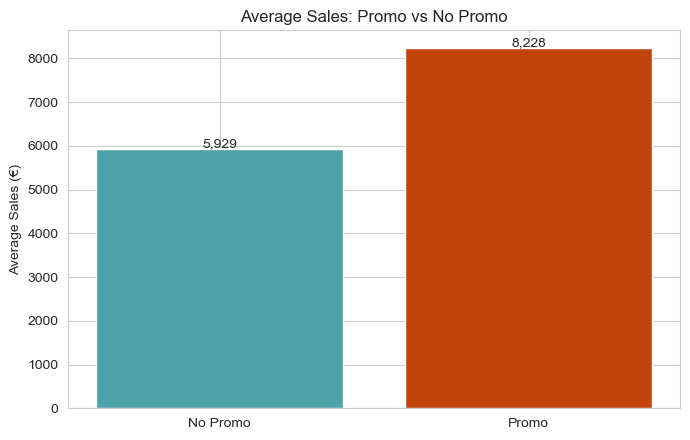

In [22]:
promo_sales = df_open.groupby('Promo')['Sales'].mean()
print(promo_sales.round(0))
print("Correlation (Sales, Promo):", round(df[['Sales','Promo']].corr().iloc[0,1], 3))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(['No Promo','Promo'], promo_sales.values, color=['#4DA1A9','#C1440E'])
ax.set_title('Average Sales: Promo vs No Promo')
ax.set_ylabel('Average Sales (€)')
for b, v in zip(bars, promo_sales.values):
    ax.text(b.get_x()+b.get_width()/2, v+50, f'{v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 2.9 StateHoliday & SchoolHoliday — holiday effects

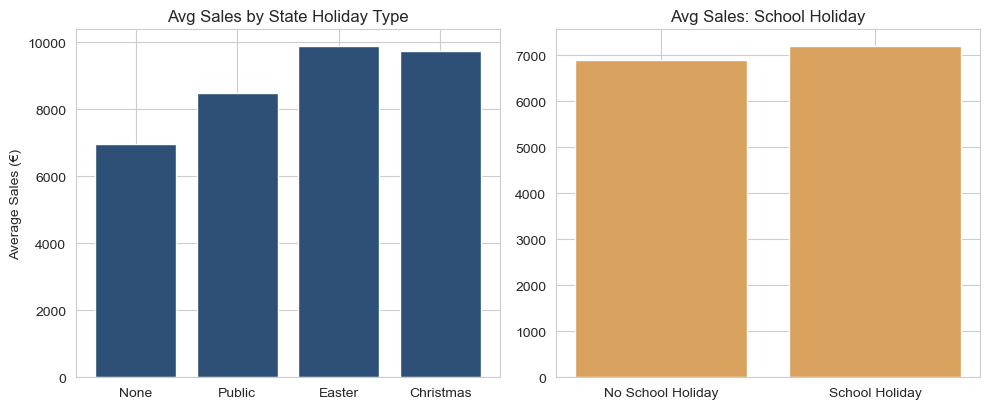

StateHoliday avg sales:
 None         6954.0
Public       8487.0
Easter       9888.0
Christmas    9744.0
Name: Sales, dtype: float64

SchoolHoliday avg sales:
 SchoolHoliday
0    6897.0
1    7200.0
Name: Sales, dtype: float64


In [23]:
sh_labels = {'0':'None','a':'Public','b':'Easter','c':'Christmas'}
sh = df_open.groupby('StateHoliday')['Sales'].mean()
sh.index = [sh_labels.get(i, i) for i in sh.index]
sch = df_open.groupby('SchoolHoliday')['Sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(sh.index, sh.values, color='#2E5077')
axes[0].set_title('Avg Sales by State Holiday Type')
axes[0].set_ylabel('Average Sales (€)')
axes[1].bar(['No School Holiday','School Holiday'], sch.values, color='#D8A25E')
axes[1].set_title('Avg Sales: School Holiday')
plt.tight_layout()
plt.show()

print("StateHoliday avg sales:\n", sh.round(0))
print("\nSchoolHoliday avg sales:\n", sch.round(0))


### 2.10 StoreType & Assortment

StoreType counts:
 StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

Assortment counts:
 Assortment
a    593
c    513
b      9
Name: count, dtype: int64


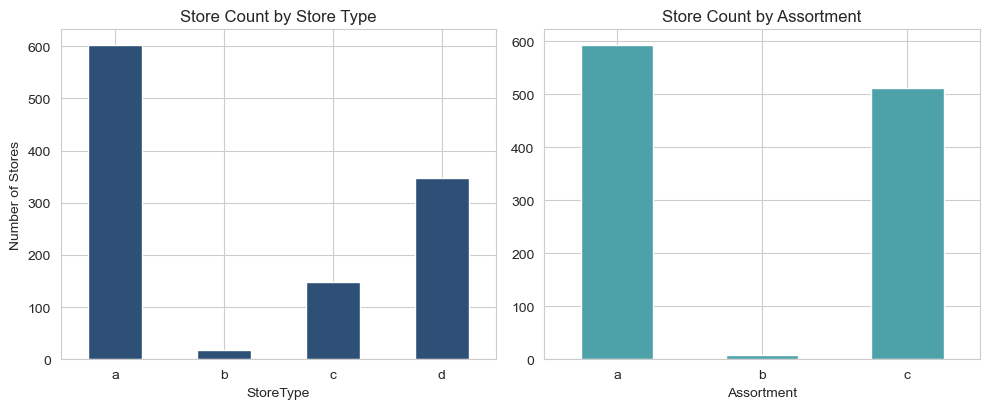

In [24]:
print("StoreType counts:\n", store['StoreType'].value_counts())
print("\nAssortment counts:\n", store['Assortment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
store['StoreType'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2E5077')
axes[0].set_title('Store Count by Store Type')
axes[0].set_ylabel('Number of Stores')
axes[0].tick_params(axis='x', rotation=0)
store['Assortment'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#4DA1A9')
axes[1].set_title('Store Count by Assortment')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


Avg Sales by StoreType:
 StoreType
b    10231.0
c     6933.0
a     6925.0
d     6822.0
Name: Sales, dtype: float64

Avg Sales by Assortment:
 Assortment
b    8639.0
c    7301.0
a    6621.0
Name: Sales, dtype: float64


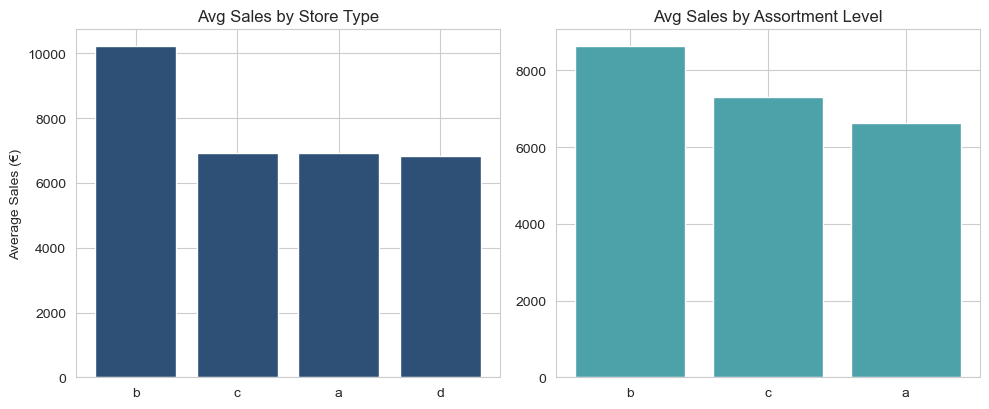

In [25]:
st = df_open.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)
asrt = df_open.groupby('Assortment')['Sales'].mean().sort_values(ascending=False)
print("Avg Sales by StoreType:\n", st.round(0))
print("\nAvg Sales by Assortment:\n", asrt.round(0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(st.index, st.values, color='#2E5077')
axes[0].set_title('Avg Sales by Store Type')
axes[0].set_ylabel('Average Sales (€)')
axes[1].bar(asrt.index, asrt.values, color='#4DA1A9')
axes[1].set_title('Avg Sales by Assortment Level')
plt.tight_layout()
plt.show()


### 2.11 CompetitionDistance & Promo2

CompetitionDistance stats:
 count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64

Correlation (Sales, CompetitionDistance): -0.019

Promo2 value counts:
 Promo2
1    571
0    544
Name: count, dtype: int64


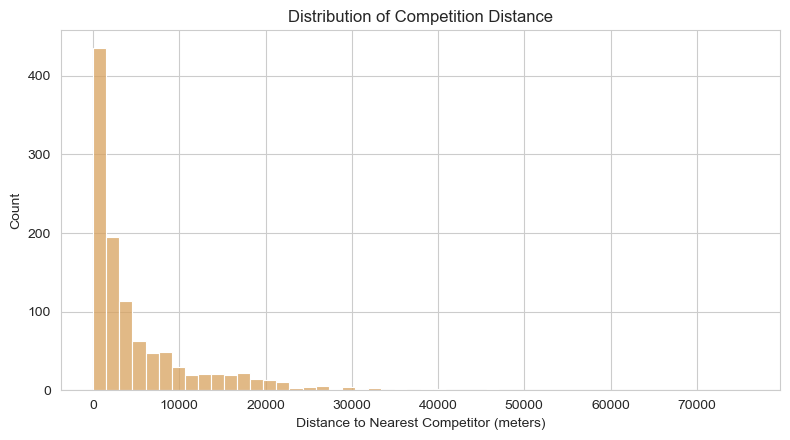

In [26]:
print("CompetitionDistance stats:\n", store['CompetitionDistance'].describe())
print("\nCorrelation (Sales, CompetitionDistance):",
      round(df[['Sales','CompetitionDistance']].corr().iloc[0,1], 3))
print("\nPromo2 value counts:\n", store['Promo2'].value_counts())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(store['CompetitionDistance'].dropna(), bins=50, color='#D8A25E', ax=ax)
ax.set_title('Distribution of Competition Distance')
ax.set_xlabel('Distance to Nearest Competitor (meters)')
plt.tight_layout()
plt.show()


## 3. Correlation Analysis

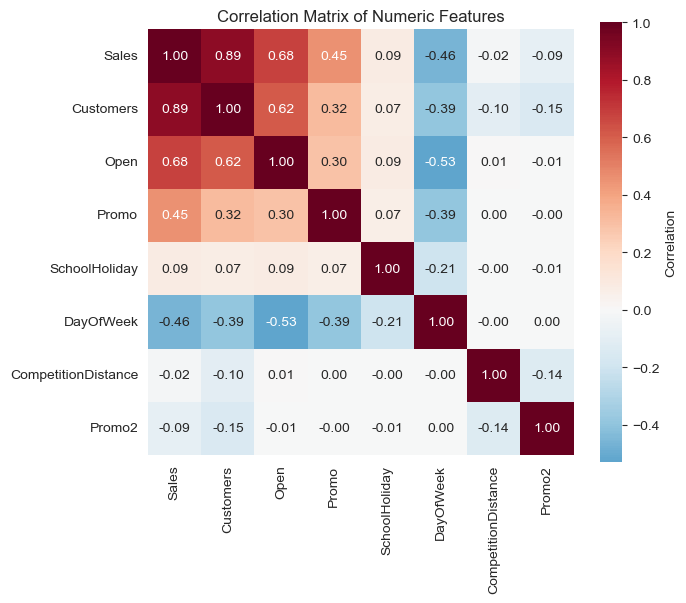

,Sales,Customers,Open,Promo,SchoolHoliday,DayOfWeek,CompetitionDistance,Promo2
Sales,1.000000,0.894711,0.678472,0.452345,0.085124,-0.462125,-0.019229,-0.091040
Customers,0.894711,1.000000,0.616768,0.316169,0.071568,-0.386445,-0.102861,-0.150159
Open,0.678472,0.616768,1.000000,0.295042,0.086171,-0.528963,0.007992,-0.008309
Promo,0.452345,0.316169,0.295042,1.000000,0.067483,-0.392925,0.000138,-0.000983
SchoolHoliday,0.085124,0.071568,0.086171,0.067483,1.000000,-0.205388,-0.003689,-0.006909
DayOfWeek,-0.462125,-0.386445,-0.528963,-0.392925,-0.205388,1.000000,-0.000025,0.000168
CompetitionDistance,-0.019229,-0.102861,0.007992,0.000138,-0.003689,-0.000025,1.000000,-0.139886
Promo2,-0.091040,-0.150159,-0.008309,-0.000983,-0.006909,0.000168,-0.139886,1.000000


In [27]:
num_cols = ['Sales','Customers','Open','Promo','SchoolHoliday','DayOfWeek',
            'CompetitionDistance','Promo2']
corr_df = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

corr_df


 ## Sales Distribution — KDE plot
 

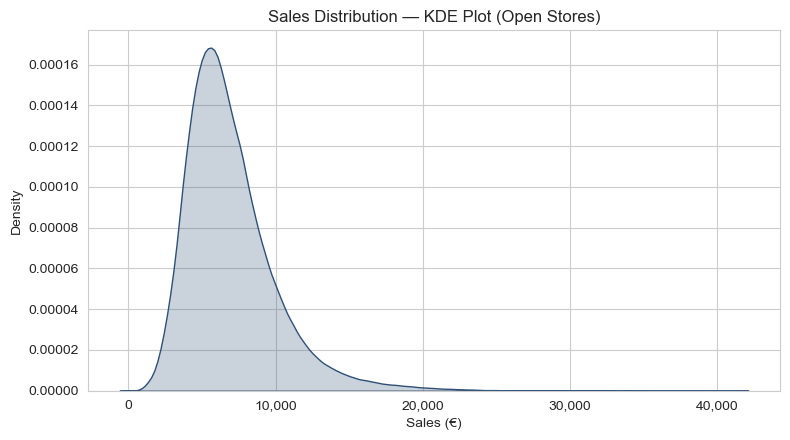

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(df_open['Sales'], color='#2E5077', fill=True, ax=ax)
ax.set_title('Sales Distribution — KDE Plot (Open Stores)')
ax.set_xlabel('Sales (€)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()


### 3b.2 Time Series Plot — Sales over time by store

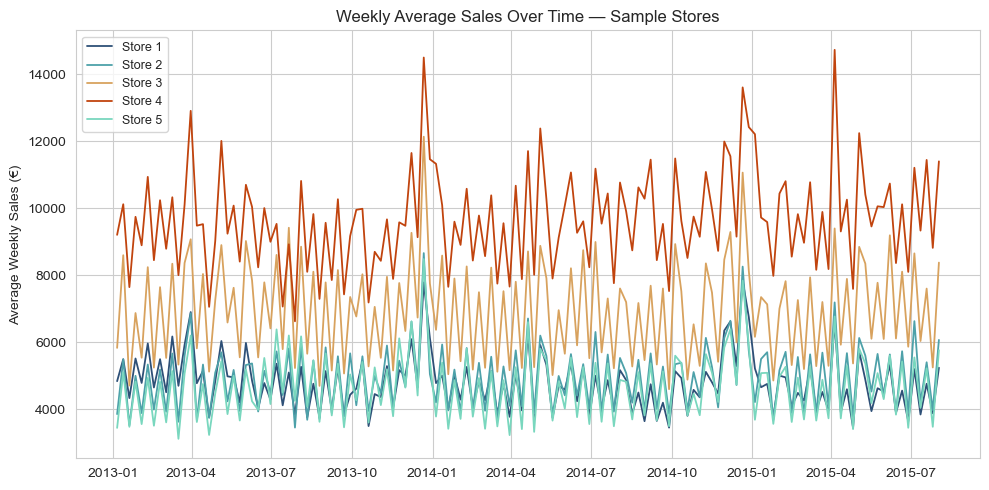

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sample_stores = [1, 2, 3, 4, 5]
colors = ['#2E5077', '#4DA1A9', '#D8A25E', '#C1440E', '#79D7BE']
for s, c in zip(sample_stores, colors):
    sdf = df_open[df_open['Store'] == s].sort_values('Date')
    weekly = sdf.set_index('Date')['Sales'].resample('W').mean()
    ax.plot(weekly.index, weekly.values, label=f'Store {s}', color=c, linewidth=1.3)
ax.set_title('Weekly Average Sales Over Time — Sample Stores')
ax.set_ylabel('Average Weekly Sales (€)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


 ### Store Comparison — Sales distribution across different stores

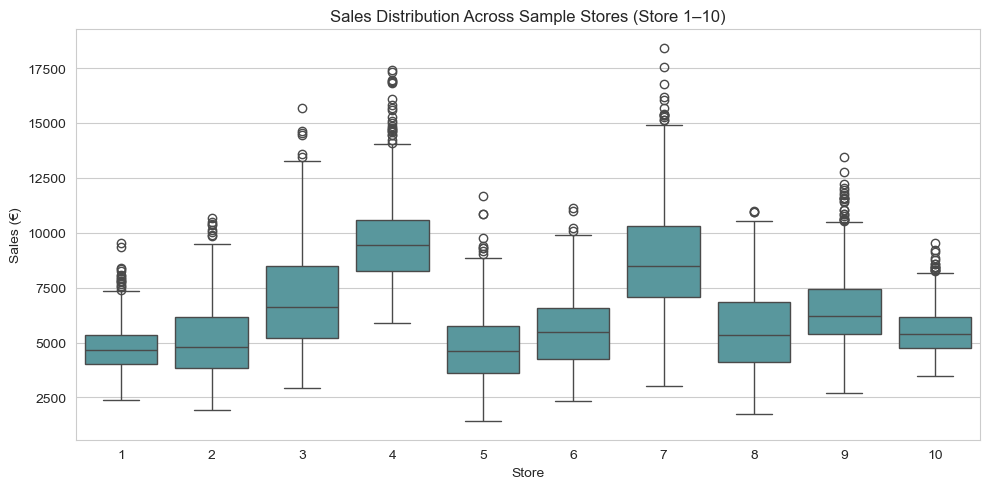

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
sample_stores2 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_df = df_open[df_open['Store'].isin(sample_stores2)]
sns.boxplot(data=plot_df, x='Store', y='Sales', ax=ax, color='#4DA1A9')
ax.set_title('Sales Distribution Across Sample Stores (Store 1–10)')
ax.set_ylabel('Sales (€)')
plt.tight_layout()
plt.show()


 Multi-feature Analysis — faceted plot (DayOfWeek × Promo × StoreType)

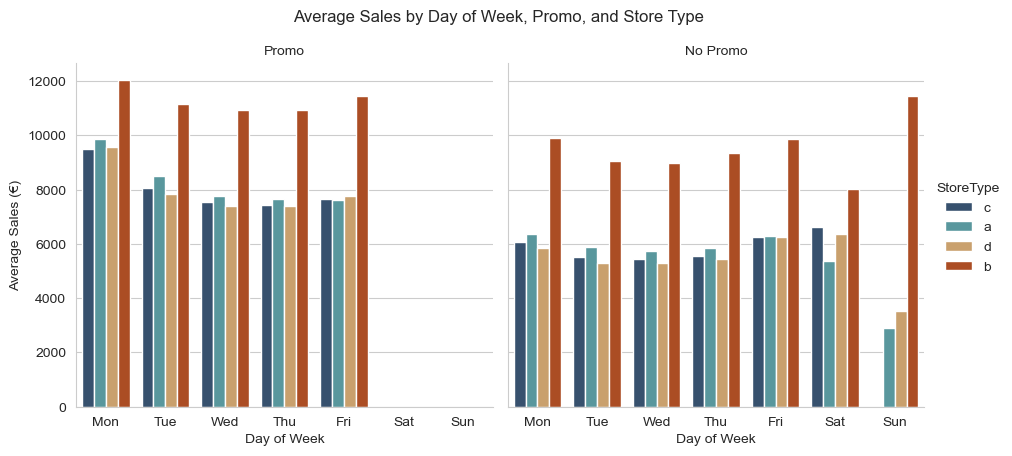

In [31]:
facet_df = df_open.copy()
facet_df['DayOfWeekName'] = facet_df['DayOfWeek'].map(
    dict(zip(range(1, 8), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
)
facet_df['PromoLabel'] = facet_df['Promo'].map({0: 'No Promo', 1: 'Promo'})
g = sns.catplot(
    data=facet_df, x='DayOfWeekName', y='Sales', col='PromoLabel', hue='StoreType',
    kind='bar', order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    height=4.3, aspect=1.1, palette=['#2E5077','#4DA1A9','#D8A25E','#C1440E'], errorbar=None,
)
g.set_axis_labels('Day of Week', 'Average Sales (€)')
g.set_titles('{col_name}')
g.fig.suptitle('Average Sales by Day of Week, Promo, and Store Type', y=1.05)
plt.show()


## 4. Key Insights & Findings

##4.1 Correlation strengths between features and Sales

In [32]:
num_cols2 = ['Customers','Promo','SchoolHoliday','DayOfWeek','CompetitionDistance','Promo2']
corr_series = df_open[num_cols2 + ['Sales']].corr()['Sales'].drop('Sales')
corr_series['Open'] = df[['Open','Sales']].corr().iloc[0,1]
corr_series = corr_series.sort_values(key=lambda s: s.abs(), ascending=False)

def strength_label(r):
    a = abs(r)
    if a >= 0.5: return 'Strong'
    elif a >= 0.3: return 'Moderate'
    elif a >= 0.1: return 'Weak'
    else: return 'Negligible'

for feat, r in corr_series.items():
    print(f"  {feat:22s} r = {r:+.3f}  ({strength_label(r)})")


  Customers              r = +0.824  (Strong)
  Open                   r = +0.678  (Strong)
  Promo                  r = +0.368  (Moderate)
  DayOfWeek              r = -0.179  (Weak)
  Promo2                 r = -0.128  (Weak)
  SchoolHoliday          r = +0.039  (Negligible)
  CompetitionDistance    r = -0.036  (Negligible)


## 4.2 High-performing vs low-performing stores

Top 10 stores by average sales:
       avg_sales  sales_std  days_open
Store                                 
817      21757.5     4674.8        784
262      20718.5     4668.9        942
1114     20666.6     3452.9        784
251      19123.1     3547.6        779
842      18574.8     3789.0        622
513      18179.1     3284.6        784
562      17969.6     2931.9        942
788      17961.9     3150.6        784
383      17294.7     2785.8        780
756      16574.8     3912.6        779

Bottom 10 stores by average sales:
       avg_sales  sales_std  days_open
Store                                 
307       2703.7     1032.8        782
543       2790.4     1237.7        781
198       2900.6     1597.8        782
208       2936.3      716.5        784
841       2972.6     1096.3        780
254       3006.0      832.1        779
794       3083.8      576.0        780
219       3133.7      822.3        779
210       3194.0      849.3        779
425       3237.7      897.2        

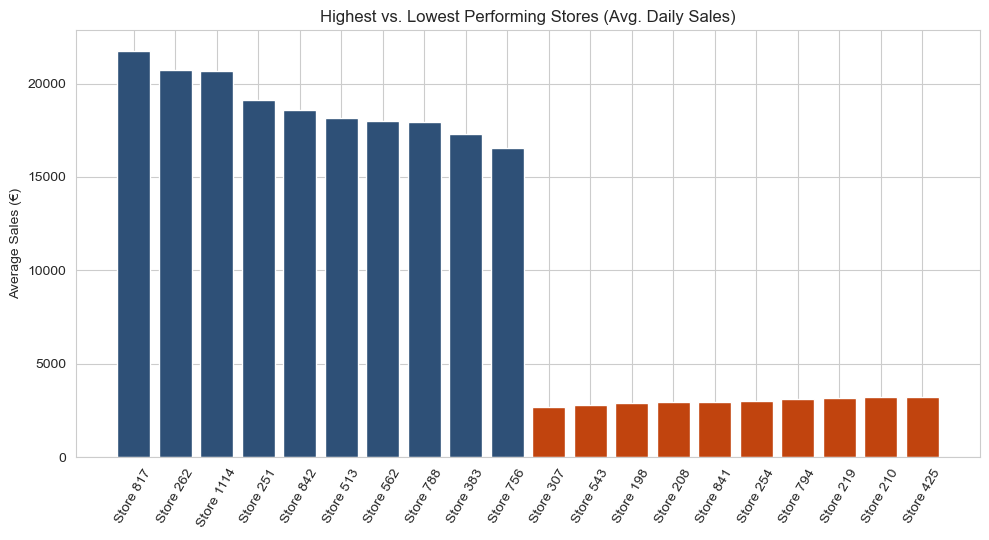

In [33]:
store_perf = df_open.groupby('Store')['Sales'].agg(['mean','std','count']).round(1)
store_perf = store_perf.rename(columns={'mean':'avg_sales','std':'sales_std','count':'days_open'})
top10 = store_perf.sort_values('avg_sales', ascending=False).head(10)
bottom10 = store_perf.sort_values('avg_sales', ascending=True).head(10)
print("Top 10 stores by average sales:")
print(top10)
print("\nBottom 10 stores by average sales:")
print(bottom10)
print(f"\nOverall store avg-sales range: €{store_perf['avg_sales'].min():,.0f} to "
      f"€{store_perf['avg_sales'].max():,.0f} "
      f"({store_perf['avg_sales'].max()/store_perf['avg_sales'].min():.1f}x spread)")

fig, ax = plt.subplots(figsize=(10, 5.5))
combo = pd.concat([top10['avg_sales'].rename('Top 10'), bottom10['avg_sales'].rename('Bottom 10')])
colors = ['#2E5077']*10 + ['#C1440E']*10
labels = [f'Store {s}' for s in top10.index] + [f'Store {s}' for s in bottom10.index]
ax.bar(labels, combo.values, color=colors)
ax.set_title('Highest vs. Lowest Performing Stores (Avg. Daily Sales)')
ax.set_ylabel('Average Sales (€)')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


## 4.3 Impact of promotions, holidays, and customer count

In [34]:
promo_lift = df_open.groupby('Promo')['Sales'].mean()
promo_pct = (promo_lift[1] / promo_lift[0] - 1) * 100
print(f"Promo uplift: €{promo_lift[0]:,.0f} -> €{promo_lift[1]:,.0f}  ({promo_pct:+.1f}%)")

sch_lift = df_open.groupby('SchoolHoliday')['Sales'].mean()
sch_pct = (sch_lift[1] / sch_lift[0] - 1) * 100
print(f"School holiday uplift: €{sch_lift[0]:,.0f} -> €{sch_lift[1]:,.0f}  ({sch_pct:+.1f}%)")

cust_corr = df_open[['Customers','Sales']].corr().iloc[0,1]
avg_basket = (df_open['Sales'] / df_open['Customers']).mean()
print(f"Customers-Sales correlation: {cust_corr:.3f} (strongest single driver of Sales)")
print(f"Average spend per customer: €{avg_basket:.2f}")


Promo uplift: €5,929 -> €8,228  (+38.8%)
School holiday uplift: €6,897 -> €7,200  (+4.4%)
Customers-Sales correlation: 0.824 (strongest single driver of Sales)
Average spend per customer: €9.49


## 4.4 Data patterns and anomalies

In [35]:
anomaly_open_zero = ((df['Open']==1) & (df['Sales']==0)).sum()
print(f"Open=1 but Sales=0: {anomaly_open_zero} rows (likely unrecorded closures)")

dup_rows = df.duplicated(subset=['Store','Date']).sum()
print(f"Duplicate Store+Date rows: {dup_rows}")

neg_sales = (df['Sales'] < 0).sum()
neg_customers = (df['Customers'] < 0).sum()
print(f"Negative Sales values: {neg_sales}")
print(f"Negative Customers values: {neg_customers}")

zero_cust_positive_sales = ((df['Customers']==0) & (df['Sales']>0)).sum()
print(f"Rows with 0 customers but Sales > 0: {zero_cust_positive_sales}")

high_sales_low_cust = df_open[df_open['Customers']>0].copy()
high_sales_low_cust['sales_per_cust'] = high_sales_low_cust['Sales'] / high_sales_low_cust['Customers']
spc_upper = high_sales_low_cust['sales_per_cust'].quantile(0.999)
print(f"99.9th percentile of Sales-per-Customer: €{spc_upper:.2f} "
      f"(useful threshold for flagging extreme per-customer spend outliers)")


Open=1 but Sales=0: 54 rows (likely unrecorded closures)
Duplicate Store+Date rows: 0
Negative Sales values: 0
Negative Customers values: 0
Rows with 0 customers but Sales > 0: 0
99.9th percentile of Sales-per-Customer: €17.27 (useful threshold for flagging extreme per-customer spend outliers)


## 4.5 Seasonal / cyclical trends

In [36]:
month_avg = df_open.groupby('Month')['Sales'].mean().round(0)
print("Avg Sales by calendar month:")
print(month_avg)

peak_month = month_avg.idxmax()
low_month = month_avg.idxmin()
print(f"\nPeak month: {peak_month} (€{month_avg[peak_month]:,.0f})  |  "
      f"Lowest month: {low_month} (€{month_avg[low_month]:,.0f})")

dow_avg = df_open.groupby('DayOfWeek')['Sales'].mean().round(0)
print(f"Peak day-of-week: {dow_avg.idxmax()}  |  Lowest day-of-week: {dow_avg.idxmin()}")
print("A clear annual cycle (Dec peak, Jan/Feb trough) and weekly cycle "
      "(Mon/Sun high, Sat low) are both present.")


Avg Sales by calendar month:
Month
1     6564.0
2     6589.0
3     6976.0
4     7046.0
5     7106.0
6     7001.0
7     6953.0
8     6649.0
9     6546.0
10    6603.0
11    7189.0
12    8609.0
Name: Sales, dtype: float64

Peak month: 12 (€8,609)  |  Lowest month: 9 (€6,546)
Peak day-of-week: 7  |  Lowest day-of-week: 6
A clear annual cycle (Dec peak, Jan/Feb trough) and weekly cycle (Mon/Sun high, Sat low) are both present.


## 5. Data Preprocessing Recommendations

## 5.1 Features requiring encoding (categorical)

In [37]:
cat_info = [
    ('StoreType', 'Nominal (a/b/c/d)', 'One-hot encoding, or target/ordinal encoding for tree models'),
    ('Assortment', 'Nominal (a/b/c)', 'One-hot encoding, or target/ordinal encoding for tree models'),
    ('StateHoliday', "Nominal ('0'/a/b/c)", "One-hot encoding; note '0' is a string, not the int 0"),
    ('PromoInterval', 'Nominal (month-list string)', "Parse into 4 binary month flags or a 'promo2 active this month' feature"),
    ('Store', 'High-cardinality ID (1,115 levels)', 'Leave as categorical for tree models; target-encode or embed for linear/NN models'),
    ('DayOfWeek', 'Cyclical ordinal (1-7)', 'Keep as-is for trees; sine/cosine encode for linear/NN models'),
]
for feat, kind, rec in cat_info:
    print(f"{feat:14s} [{kind}]\n    -> {rec}")


StoreType      [Nominal (a/b/c/d)]
    -> One-hot encoding, or target/ordinal encoding for tree models
Assortment     [Nominal (a/b/c)]
    -> One-hot encoding, or target/ordinal encoding for tree models
StateHoliday   [Nominal ('0'/a/b/c)]
    -> One-hot encoding; note '0' is a string, not the int 0
PromoInterval  [Nominal (month-list string)]
    -> Parse into 4 binary month flags or a 'promo2 active this month' feature
Store          [High-cardinality ID (1,115 levels)]
    -> Leave as categorical for tree models; target-encode or embed for linear/NN models
DayOfWeek      [Cyclical ordinal (1-7)]
    -> Keep as-is for trees; sine/cosine encode for linear/NN models


## 5.2 Scaling / normalization strategies

In [38]:
scale_info = [
    ('Sales (target)', 'Right-skewed, wide range (€0-41,551)',
     'Apply log1p transform to stabilize variance; invert with expm1 for final predictions'),
    ('Customers', 'Right-skewed, correlated with Sales',
     'Log-transform if used as a feature; StandardScaler for linear/NN models'),
    ('CompetitionDistance', 'Right-skewed, spans 20-75,860m',
     'Log-transform or RobustScaler (robust to the large-distance outliers)'),
    ('Promo2SinceWeek / CompetitionOpenSinceMonth-Year', 'Different units/scales',
     "Convert to a single 'months since competition opened' / 'weeks since Promo2 started' feature, then scale"),
]
for feat, note, rec in scale_info:
    print(f"{feat:55s} ({note})\n    -> {rec}")
print("\nNote: tree-based models (Random Forest / XGBoost / LightGBM) are scale-invariant, "
      "so scaling mainly matters if a linear or neural-network model is also being tried.")


Sales (target)                                          (Right-skewed, wide range (€0-41,551))
    -> Apply log1p transform to stabilize variance; invert with expm1 for final predictions
Customers                                               (Right-skewed, correlated with Sales)
    -> Log-transform if used as a feature; StandardScaler for linear/NN models
CompetitionDistance                                     (Right-skewed, spans 20-75,860m)
    -> Log-transform or RobustScaler (robust to the large-distance outliers)
Promo2SinceWeek / CompetitionOpenSinceMonth-Year        (Different units/scales)
    -> Convert to a single 'months since competition opened' / 'weeks since Promo2 started' feature, then scale

Note: tree-based models (Random Forest / XGBoost / LightGBM) are scale-invariant, so scaling mainly matters if a linear or neural-network model is also being tried.


## 5.3 Feature engineering opportunities

In [39]:
fe_ideas = [
    'Extract Year, Month, Day, WeekOfYear from Date.',
    'Days/weeks until or since the nearest StateHoliday or SchoolHoliday.',
    "CompetitionOpenSinceMonth + CompetitionOpenSinceYear -> 'months since competitor opened' "
    "(0/negative if not yet open, large value if missing = no competitor).",
    "Promo2SinceWeek + Promo2SinceYear + PromoInterval -> binary 'Promo2 active this month' flag "
    "per row instead of the raw start date fields.",
    'Rolling averages of Sales / Customers per store (e.g. 7-day, 30-day) as lag features '
    '(careful to avoid leakage across the train/test boundary).',
    'Store-level aggregates: historical average Sales, average Customers, '
    'and Promo participation rate as store-level features.',
    'Interaction features suggested by the EDA: Promo x DayOfWeek, StoreType x Assortment, '
    'StoreType x Promo (Section 3/3b showed these combinations shift average sales materially).',
]
for idea in fe_ideas:
    print(f"- {idea}")


- Extract Year, Month, Day, WeekOfYear from Date.
- Days/weeks until or since the nearest StateHoliday or SchoolHoliday.
- CompetitionOpenSinceMonth + CompetitionOpenSinceYear -> 'months since competitor opened' (0/negative if not yet open, large value if missing = no competitor).
- Promo2SinceWeek + Promo2SinceYear + PromoInterval -> binary 'Promo2 active this month' flag per row instead of the raw start date fields.
- Rolling averages of Sales / Customers per store (e.g. 7-day, 30-day) as lag features (careful to avoid leakage across the train/test boundary).
- Store-level aggregates: historical average Sales, average Customers, and Promo participation rate as store-level features.
- Interaction features suggested by the EDA: Promo x DayOfWeek, StoreType x Assortment, StoreType x Promo (Section 3/3b showed these combinations shift average sales materially).


## 5.4 Necessary data cleaning steps

In [40]:
cleaning_steps = [
    f"Impute the {test['Open'].isnull().sum()} missing test.csv Open values "
    "(all Store 622 in Sept 2015) — reasonable default is 1 (open), matching that store's normal pattern.",
    f"Investigate/drop or relabel the {((df['Open']==1)&(df['Sales']==0)).sum()} rows where Open=1 but Sales=0 "
    "(likely unrecorded closures); leaving them as-is will teach the model an incorrect zero-sales pattern.",
    'Filter out Open=0 rows before training a Sales regressor (or model closures as a separate zero-inflation step), '
    'since Sales is deterministically 0 whenever a store is closed.',
    'Fill missing CompetitionDistance (3 stores) with the median or a large constant, and add a missing-flag column.',
    "Fill missing CompetitionOpenSinceMonth/Year and Promo2SinceWeek/Year/PromoInterval with 0 / 'never' "
    'plus an explicit indicator flag, rather than dropping the 354/544 affected stores.',
    "Standardize StateHoliday's '0' (string zero) so it isn't accidentally treated as numeric 0 during encoding.",
    'Confirm no duplicate Store+Date rows exist before merging/training (checked above).',
]
for step in cleaning_steps:
    print(f"- {step}")


- Impute the 11 missing test.csv Open values (all Store 622 in Sept 2015) — reasonable default is 1 (open), matching that store's normal pattern.
- Investigate/drop or relabel the 54 rows where Open=1 but Sales=0 (likely unrecorded closures); leaving them as-is will teach the model an incorrect zero-sales pattern.
- Filter out Open=0 rows before training a Sales regressor (or model closures as a separate zero-inflation step), since Sales is deterministically 0 whenever a store is closed.
- Fill missing CompetitionDistance (3 stores) with the median or a large constant, and add a missing-flag column.
- Fill missing CompetitionOpenSinceMonth/Year and Promo2SinceWeek/Year/PromoInterval with 0 / 'never' plus an explicit indicator flag, rather than dropping the 354/544 affected stores.
- Standardize StateHoliday's '0' (string zero) so it isn't accidentally treated as numeric 0 during encoding.
- Confirm no duplicate Store+Date rows exist before merging/training (checked above).
